In [4]:
# Imports
import os
import sys
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy, pearsonr, spearmanr

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)

from src.dataloader import get_dataloaders
from src.model import DissagreementPredictor

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FIGURES_DIR = PROJECT_ROOT / "figures"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DEVICE

device(type='cpu')

In [5]:
# Load model helpers and test data
def load_cifar_batch(batch_path):
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=r"dtype\(\): align should be passed as Python or NumPy boolean.*",
            category=np.exceptions.VisibleDeprecationWarning,
        )
        with open(batch_path, "rb") as f:
            batch = pickle.load(f, encoding="bytes")
    return batch[b"data"]

images = load_cifar_batch(PROJECT_ROOT / "data/raw/cifar-10-batches-py/test_batch")
probs = np.load(PROJECT_ROOT / "data/raw/cifar10h-probs.npy")
_, _, test_loader = get_dataloaders(images, probs)

len(test_loader.dataset)

2000

In [8]:
# Inference and metrics
def run_inference(model, data_loader):
    all_preds = []
    all_true = []

    model.eval()
    with torch.no_grad():
        for imgs, targets in data_loader:
            imgs = imgs.to(DEVICE)
            preds = model(imgs)
            all_preds.append(preds.cpu().numpy())
            all_true.append(targets.numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_true = np.concatenate(all_true, axis=0)
    return all_preds, all_true


def compute_distribution_metrics(all_preds, all_true, eps=1e-8):
    preds = np.clip(all_preds, eps, 1.0)
    true = np.clip(all_true, eps, 1.0)

    kl_values = np.sum(true * (np.log(true) - np.log(preds)), axis=1)
    jsd_values = np.array([jensenshannon(t, p) ** 2 for t, p in zip(true, preds)])
    cosine_values = np.sum(true * preds, axis=1) / (
        np.linalg.norm(true, axis=1) * np.linalg.norm(preds, axis=1) + eps
    )

    return {
        "kl_mean": float(np.mean(kl_values)),
        "kl_std": float(np.std(kl_values)),
        "jsd_mean": float(np.mean(jsd_values)),
        "jsd_std": float(np.std(jsd_values)),
        "cosine_mean": float(np.mean(cosine_values)),
        "cosine_std": float(np.std(cosine_values)),
        "kl_values": kl_values,
        "jsd_values": jsd_values,
        "cosine_values": cosine_values,
    }


def compute_entropy_metrics(all_preds, all_true, eps=1e-8):
    preds = np.clip(all_preds, eps, 1.0)
    true = np.clip(all_true, eps, 1.0)

    true_entropy = entropy(true, base=2, axis=1)
    pred_entropy = entropy(preds, base=2, axis=1)
    pearson_corr, _ = pearsonr(true_entropy, pred_entropy)
    spearman_corr, _ = spearmanr(true_entropy, pred_entropy)

    return {
        "true_entropy": true_entropy,
        "pred_entropy": pred_entropy,
        "pearson": float(pearson_corr),
        "spearman": float(spearman_corr),
    }


def precision_at_k(true_entropy, pred_entropy, k):
    true_topk = set(np.argsort(true_entropy)[-k:])
    pred_topk = set(np.argsort(pred_entropy)[-k:])
    return float(len(true_topk & pred_topk) / k)


def plot_entropy_scatter(true_entropy, pred_entropy, loss_name):
    plt.figure(figsize=(6, 6))
    plt.scatter(true_entropy, pred_entropy, alpha=0.35, s=12)
    min_val = min(true_entropy.min(), pred_entropy.min())
    max_val = max(true_entropy.max(), pred_entropy.max())
    plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1)
    plt.xlabel("True Entropy")
    plt.ylabel("Predicted Entropy")
    plt.title(f"Entropy Scatter: {loss_name.upper()}")
    plt.tight_layout()
    output_path = FIGURES_DIR / f"entropy_scatter_{loss_name}.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    return output_path


def resolve_checkpoint_path(model_path):
    model_path = Path(model_path)
    if model_path.exists():
        return model_path

    candidate_names = [
        model_path.name,
        model_path.name.replace("best_model_", "best_model _"),
        model_path.name.replace(" ", ""),
    ]

    for candidate_name in candidate_names:
        candidate_path = model_path.with_name(candidate_name)
        if candidate_path.exists():
            return candidate_path

    matches = sorted(model_path.parent.glob(f"*{model_path.stem.split('_')[-1]}*.pt"))
    if len(matches) == 1:
        return matches[0]

    raise FileNotFoundError(
        f"Could not find checkpoint for {model_path.name}. Available files: "
        f"{sorted(path.name for path in model_path.parent.glob('*'))}"
    )


def evaluate_model(model_path):
    model_path = resolve_checkpoint_path(model_path)
    loss_name = model_path.stem.replace("best_model_", "").replace("best_model _", "")

    model = DissagreementPredictor().to(DEVICE)
    state_dict = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(state_dict)

    all_preds, all_true = run_inference(model, test_loader)

    distribution_metrics = compute_distribution_metrics(all_preds, all_true)
    entropy_metrics = compute_entropy_metrics(all_preds, all_true)

    p100 = precision_at_k(entropy_metrics["true_entropy"], entropy_metrics["pred_entropy"], 100)
    p200 = precision_at_k(entropy_metrics["true_entropy"], entropy_metrics["pred_entropy"], 200)
    p500 = precision_at_k(entropy_metrics["true_entropy"], entropy_metrics["pred_entropy"], 500)

    plot_path = plot_entropy_scatter(
        entropy_metrics["true_entropy"],
        entropy_metrics["pred_entropy"],
        loss_name,
    )

    results = {
        "loss": loss_name.upper(),
        "model_path": str(model_path),
        "all_preds": all_preds,
        "all_true": all_true,
        "plot_path": str(plot_path),
        "kl_mean": distribution_metrics["kl_mean"],
        "kl_std": distribution_metrics["kl_std"],
        "jsd_mean": distribution_metrics["jsd_mean"],
        "jsd_std": distribution_metrics["jsd_std"],
        "cosine_mean": distribution_metrics["cosine_mean"],
        "cosine_std": distribution_metrics["cosine_std"],
        "pearson": entropy_metrics["pearson"],
        "spearman": entropy_metrics["spearman"],
        "p_at_100": p100,
        "p_at_200": p200,
        "p_at_500": p500,
        "true_entropy": entropy_metrics["true_entropy"],
        "pred_entropy": entropy_metrics["pred_entropy"],
    }

    print(f"Loss: {results['loss']}")
    print(f"KL divergence      : {results['kl_mean']:.6f} ± {results['kl_std']:.6f}")
    print(f"JSD                : {results['jsd_mean']:.6f} ± {results['jsd_std']:.6f}")
    print(f"Cosine similarity  : {results['cosine_mean']:.6f} ± {results['cosine_std']:.6f}")
    print(f"Pearson correlation: {results['pearson']:.6f}")
    print(f"Spearman correlation: {results['spearman']:.6f}")
    print(f"Precision@100      : {results['p_at_100']:.6f}")
    print(f"Precision@200      : {results['p_at_200']:.6f}")
    print(f"Precision@500      : {results['p_at_500']:.6f}")

    return results

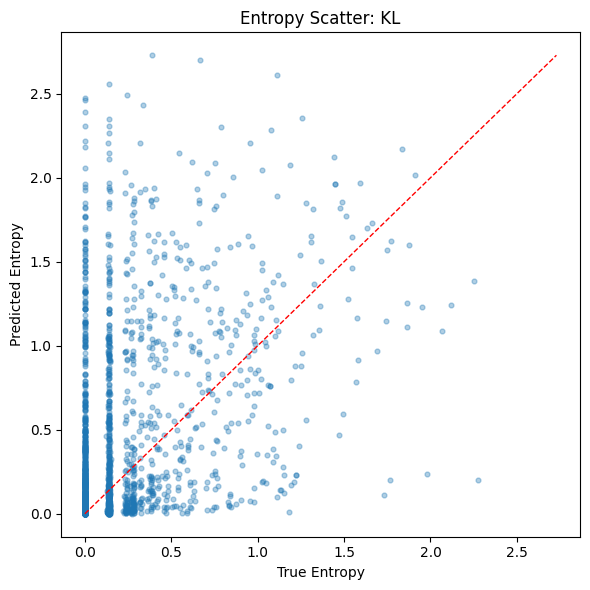

Loss: KL
KL divergence      : 0.287135 ± 0.669755
JSD                : 0.059497 ± 0.122782
Cosine similarity  : 0.924809 ± 0.208997
Pearson correlation: 0.405671
Spearman correlation: 0.362558
Precision@100      : 0.220000
Precision@200      : 0.275000
Precision@500      : 0.500000


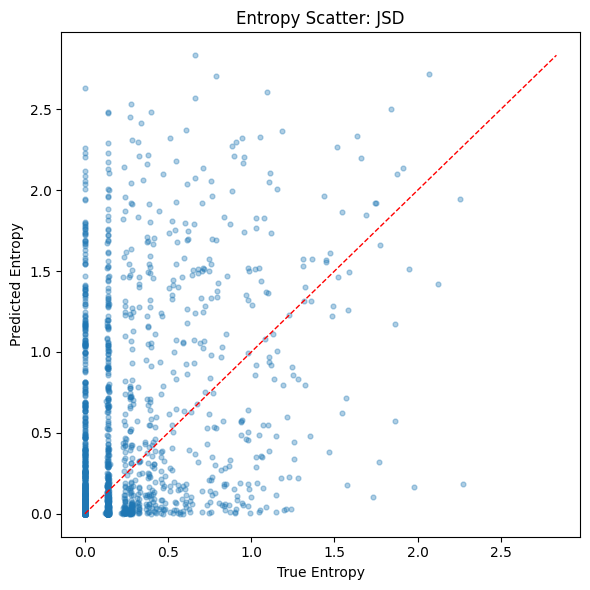

Loss: JSD
KL divergence      : 0.351937 ± 0.779344
JSD                : 0.068460 ± 0.137017
Cosine similarity  : 0.909737 ± 0.230769
Pearson correlation: 0.388623
Spearman correlation: 0.327434
Precision@100      : 0.220000
Precision@200      : 0.320000
Precision@500      : 0.462000


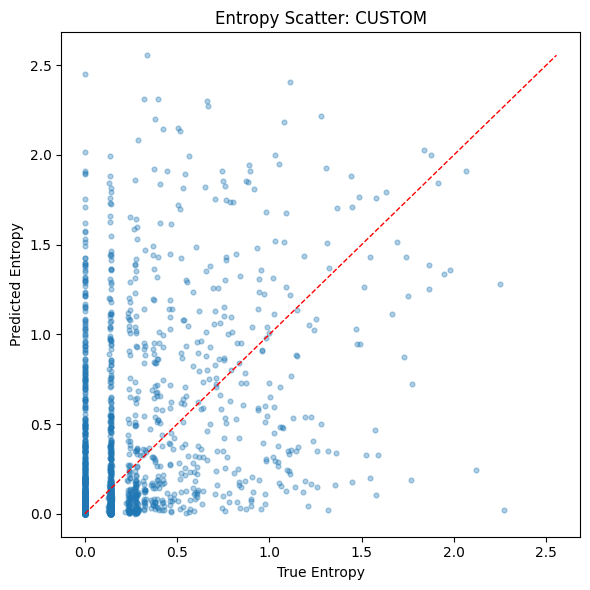

Loss: CUSTOM
KL divergence      : 0.309452 ± 0.804972
JSD                : 0.056747 ± 0.127277
Cosine similarity  : 0.926292 ± 0.214480
Pearson correlation: 0.420535
Spearman correlation: 0.394943
Precision@100      : 0.230000
Precision@200      : 0.340000
Precision@500      : 0.504000


In [9]:
# Entropy analysis and visualization per model
kl_results = evaluate_model(CHECKPOINTS_DIR / "best_model_kl.pt")
jsd_results = evaluate_model(CHECKPOINTS_DIR / "best_model_jsd.pt")
custom_results = evaluate_model(CHECKPOINTS_DIR / "best_model_custom.pt")

In [10]:
# Precision@K and final comparison table
comparison_df = pd.DataFrame([
    {
        "Loss": kl_results["loss"],
        "KL": kl_results["kl_mean"],
        "JSD": kl_results["jsd_mean"],
        "Cosine": kl_results["cosine_mean"],
        "Pearson": kl_results["pearson"],
        "Spearman": kl_results["spearman"],
        "P@100": kl_results["p_at_100"],
        "P@200": kl_results["p_at_200"],
        "P@500": kl_results["p_at_500"],
    },
    {
        "Loss": jsd_results["loss"],
        "KL": jsd_results["kl_mean"],
        "JSD": jsd_results["jsd_mean"],
        "Cosine": jsd_results["cosine_mean"],
        "Pearson": jsd_results["pearson"],
        "Spearman": jsd_results["spearman"],
        "P@100": jsd_results["p_at_100"],
        "P@200": jsd_results["p_at_200"],
        "P@500": jsd_results["p_at_500"],
    },
    {
        "Loss": custom_results["loss"],
        "KL": custom_results["kl_mean"],
        "JSD": custom_results["jsd_mean"],
        "Cosine": custom_results["cosine_mean"],
        "Pearson": custom_results["pearson"],
        "Spearman": custom_results["spearman"],
        "P@100": custom_results["p_at_100"],
        "P@200": custom_results["p_at_200"],
        "P@500": custom_results["p_at_500"],
    },
])

comparison_df = comparison_df[["Loss", "KL", "JSD", "Cosine", "Pearson", "Spearman", "P@100", "P@200", "P@500"]]
comparison_df

,Loss,KL,JSD,Cosine,Pearson,Spearman,P@100,P@200,P@500
0,KL,0.287135,0.059497,0.924809,0.405671,0.362558,0.22,0.275,0.500
1,JSD,0.351937,0.068460,0.909737,0.388623,0.327434,0.22,0.320,0.462
2,CUSTOM,0.309452,0.056747,0.926292,0.420535,0.394943,0.23,0.340,0.504
